In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import seaborn.objects as so
from pathlib import Path

from jiflr import ROOT

plt.style.use('default')

# Load files

In [2]:
p = Path(
    "/Users/drotto/src/jiflr/data/external/JIRP_MASSBALANCE_2024/JIRP-Mass-Balance/glacier-mass-balance-code/data/Taku/Output/Output_Taku_Adjusted_Point_Balances.csv")
b_adjpt = pd.read_csv(p, parse_dates=['mass_maximum_date', 'mass_minimum_date'])

p = Path("/Users/drotto/src/jiflr/data/external/JIRP_MASSBALANCE_2024/JIRP-Mass-Balance/Raw Snowpit Data")
ps = sorted(list(p.glob('[0-9]*')))

ds = []
for p in ps:
    d = pd.read_excel(p)
    d = d[~d.map(lambda x: x in ['#REF!', '#VALUE!']).any(axis=1)]
    yr = int(p.name.split("_")[0])
    d['Year'] = yr
    ds.append(d)
b_raw = pd.concat(ds, ignore_index=True)    

b_raw.head(10)

/Users/drotto/micromamba/envs/jiflr/lib/python3.11/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


,Glacier,Snowpit,Easting(m),Northing(m),Elevation (m),Date,Snow Depth (cm),Adjusted S.W.E.(cm),Mean Snow Density(g/cm^3),Standard Deviation,Mean ablation Rate,Days till 8/10,Total Ablation(cm),Total Ablation S.W.E. (cm),Year,AdjSWE/Depth (includes ice lenses)
0,Taku Glacier,TKGSP4.10,545594,6500605,1100,1949-08-14 00:00:00,451,248.05,0.55,0,NaN,NaN,NaN,NaN,1949,NaN
1,Taku Glacier,TKGSP4,0,0,1082,1950-07-22 00:00:00,190,104.5,0.55,0,NaN,NaN,NaN,NaN,1950,NaN
2,Taku Glacier,TKGSP4,544299,6499596,1082,1951-06-07 00:00:00,340,187.0,0.55,0,NaN,NaN,NaN,NaN,1951,NaN
3,Taku Glacier,TKGSP4.10,0,0,1090,1952-08-23 00:00:00,155,85.25,0.55,0,NaN,NaN,NaN,NaN,1952,NaN
4,Taku Glacier,TKGSPD,0,0,600,1952-07-07 00:00:00,70,38.5,0.55,0,NaN,NaN,NaN,NaN,1952,NaN
5,Taku Glacier,TKGSP4,0,0,1082,8/20/195,180,99.0,0.55,0,NaN,NaN,NaN,NaN,1952,NaN
6,Taku Glacier,TKGSPF,0,0,838,1952-07-09 00:00:00,210,115.5,0.55,0,NaN,NaN,NaN,NaN,1952,NaN
7,Taku Glacier,TKGSPE,0,0,746,1952-07-09 00:00:00,135,74.25,0.55,0,NaN,NaN,NaN,NaN,1952,NaN
8,Taku Glacier,C16SP1,0,0,1460,1952-08-13 00:00:00,240,132.0,0.55,0,NaN,NaN,NaN,NaN,1952,NaN
9,Taku Glacier,MGSP1,0,0,1411,1952-08-13 00:00:00,245,134.75,0.55,0,NaN,NaN,NaN,NaN,1952,NaN


/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_71447/3203016376.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(index)


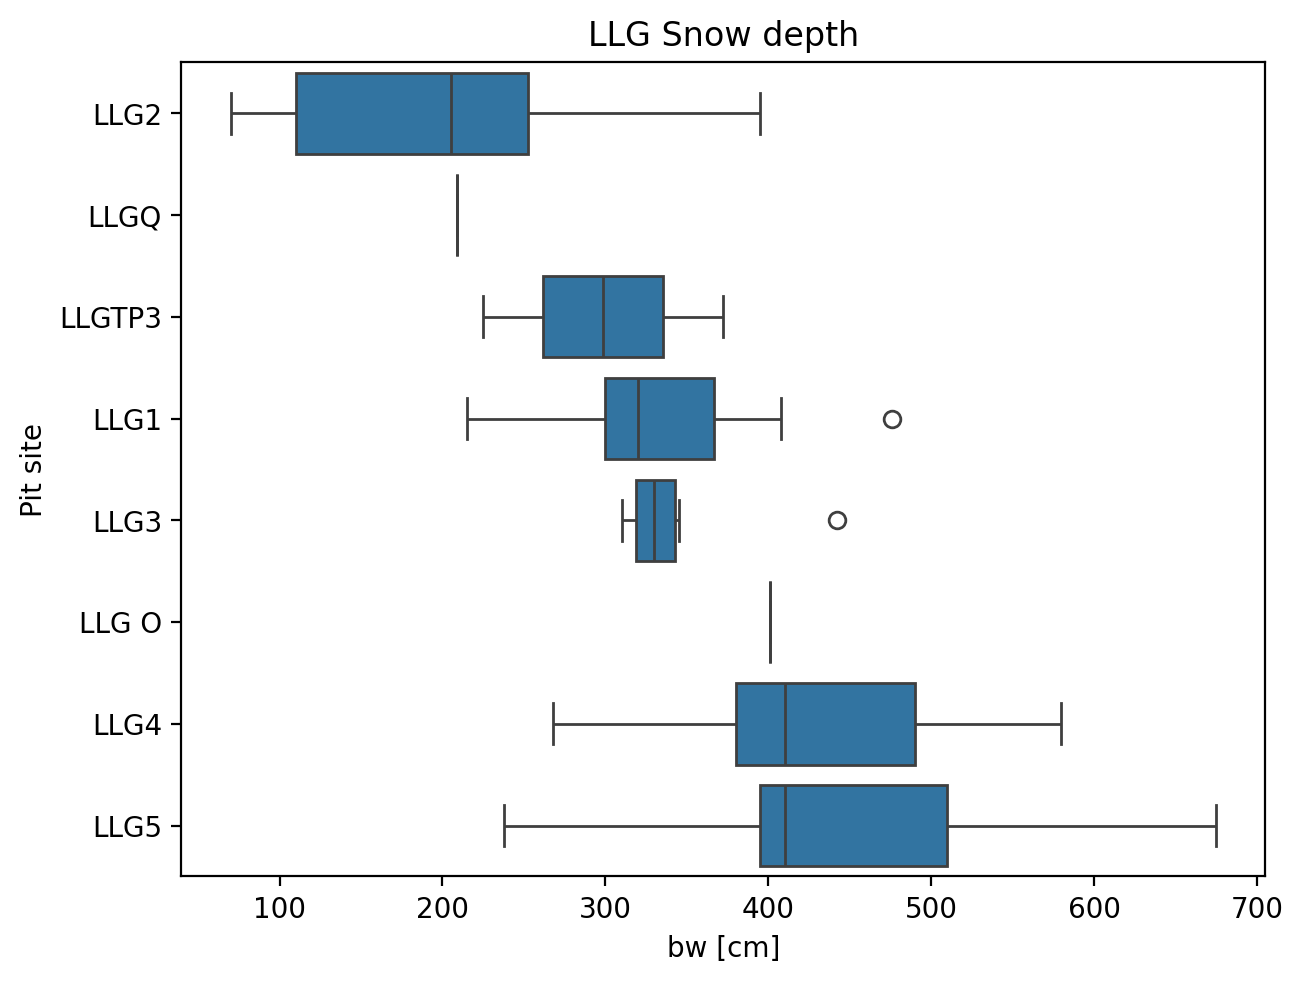

In [37]:
llg_snow = b_raw.loc[b_raw.Snowpit.str.startswith("LL")]
llg_snow = llg_snow.rename(columns={
    " Snow Depth (cm)"         : "snow_depth_cm",
    "Adjusted S.W.E.(cm)"      : "adj_swe_cm",
    "Mean Snow Density(g/cm^3)": "mean_snow_density_gcm3",
    "Snowpit": "site_name",
})

# plot winter balance range for each site.
index = llg_snow.groupby('site_name')['snow_depth_cm'].median().sort_values().index
fig, ax = plt.subplots(dpi=200, layout="constrained")
sns.boxplot(x=llg_snow.snow_depth_cm, y=llg_snow.site_name, ax=ax, orient='y', order=index)
ax.set_yticklabels(index)
ax.set_ylabel("Pit site")
ax.set_xlabel("bw [cm]")
ax.set_title("LLG Snow depth")
fig.savefig(Path(ROOT, "notebooks/estimate-post-pit-melt/llg-snow-depth-by-site.png"))

# Clean data

In [3]:
numeric_cols = [col for col in b_raw.columns if col not in ['Glacier', 'Snowpit', 'Date']]
b_raw.loc[:, numeric_cols] = b_raw.loc[:, numeric_cols].apply(pd.to_numeric, errors='coerce', axis=1)
mask = b_raw["Elevation (m)"].isin([np.nan, 0.0])
b_raw = b_raw[~mask]
b_raw['Snowpit'] = b_raw["Snowpit"].str.replace('SP', '')  # make old pit names match current
b_raw['Snowpit'] = b_raw["Snowpit"].str.replace('(\.[0-9])*', '', regex=True)  # make old pit names match current
b_raw['Snowpit'] = b_raw["Snowpit"].str.replace('-|#', '', regex=True)  # make old pit names match current
#b_raw = b_raw.loc[b_raw["Snowpit"].isin(b_adjpt['site_name'])]

# merge with processed point data
b = b_adjpt.merge(b_raw, how='inner', left_on=['Year', 'site_name'], right_on=['Year', 'Snowpit'])
b = b.rename(columns={
    " Snow Depth (cm)"         : "snow_depth_cm",
    "Adjusted S.W.E.(cm)"      : "adj_swe_cm",
    "Mean Snow Density(g/cm^3)": "mean_snow_density_gcm3",
})
b = b.drop(columns=['Elevation (m)', "Mean ablation Rate", "Days till 8/10", "Total Ablation(cm)",
                    "Total Ablation S.W.E. (cm)", "AdjSWE/Depth (includes ice lenses)"])
b = b.rename(columns={
    "Date"              : "pit_date",
    "Standard Deviation": "snow_density_std",
})
b['pit_date'] = pd.to_datetime(b['pit_date'])
b['pit_doy'] = b['pit_date'].dt.dayofyear

# filter to midsummer days
b = b.loc[(b['pit_doy'] > 180) & (b['pit_doy'] < 250)]

# filter bad data
b = b.loc[b['mean_snow_density_gcm3'] > 0.1]

b.head(10)

,Year,site_name,elevation,bw,bs,ba,mass_maximum_date,mass_minimum_date,Lapse_Rate,Time_System,...,Glacier,Snowpit,Easting(m),Northing(m),pit_date,snow_depth_cm,adj_swe_cm,mean_snow_density_gcm3,snow_density_std,pit_doy
0,1995,TKG5,991.0,2.14,-3.52,-1.38,1995-04-18,1995-10-06,-5,Fixed_Date_Stratigraphic,...,Taku Glacier,TKG5,547697.0,6496299.0,1995-07-23,120.0,74.134,0.613,0.024042,204.0
1,1995,DG1,1023.0,2.25,-3.32,-1.06,1995-04-18,1995-10-06,-5,Fixed_Date_Stratigraphic,...,Taku Glacier,DG1,550823.0,6498009.0,1995-07-28,130.0,73.0755,0.5595,0.046314,209.0
2,1995,SWB2,1064.0,2.41,-3.04,-0.63,1995-04-18,1995-10-06,-5,Fixed_Date_Stratigraphic,...,Taku Glacier,SWB2,544086.0,6495359.0,1995-07-22,155.0,94.284,0.586,0.024576,203.0
3,1995,TKG4,1110.0,2.57,-2.58,-0.01,1995-04-18,1995-10-06,-5,Fixed_Date_Stratigraphic,...,Taku Glacier,TKG4,544650.93,6499406.45,1995-07-23,196.0,113.941333,0.581333,0.021572,204.0
4,1995,TKG2,1182.0,2.60,-2.43,0.17,1995-04-18,1995-10-06,-5,Fixed_Date_Stratigraphic,...,Taku Glacier,TKG2,539081.0,6504548.0,1995-07-24,210.0,122.856,0.582,0.024055,205.0
5,1995,MG1,1419.0,2.24,-1.86,0.38,1995-04-18,1995-10-06,-5,Fixed_Date_Stratigraphic,...,Taku Glacier,MG1,545875.0,6509119.0,1995-08-01,205.0,116.66,0.5608,0.031388,213.0
6,1995,MG3,1785.0,2.70,-0.87,1.83,1995-04-18,1995-10-06,-5,Fixed_Date_Stratigraphic,...,Taku Glacier,MG3,545674.0,6520421.0,1995-08-05,420.0,222.22075,0.51725,0.0569,217.0
7,1996,TKG5,991.0,2.13,-2.50,-0.37,1996-04-30,1996-09-20,-5,Fixed_Date_Stratigraphic,...,Taku Glacier,TKG5,547697.0,6496299.0,1996-07-24,133.0,85.75,0.6284,0.088627,206.0
8,1996,DG1,1030.0,1.96,-2.63,-0.67,1996-04-30,1996-09-20,-5,Fixed_Date_Stratigraphic,...,Taku Glacier,DG1,550414.0,6498464.0,1996-07-24,125.0,69.6536,0.5488,0.028934,206.0
9,1996,TKG4,1110.0,2.32,-2.11,0.21,1996-04-30,1996-09-20,-5,Fixed_Date_Stratigraphic,...,Taku Glacier,TKG4,544650.93,6499406.45,1996-07-25,200.0,111.415714,0.548286,0.035991,207.0


In [26]:
b.loc[b.site_name.str.startswith("LL")].groupby('site_name').median(numeric_only=True)

,Year,elevation,bw,bs,ba,Lapse_Rate,pit_doy
site_name,,,,,,,
LLG5,2011.5,1871.0,2.56,-0.055,2.43,-5.0,214.5


# Plot results

# Estimate post-pit melt

The following plots show...

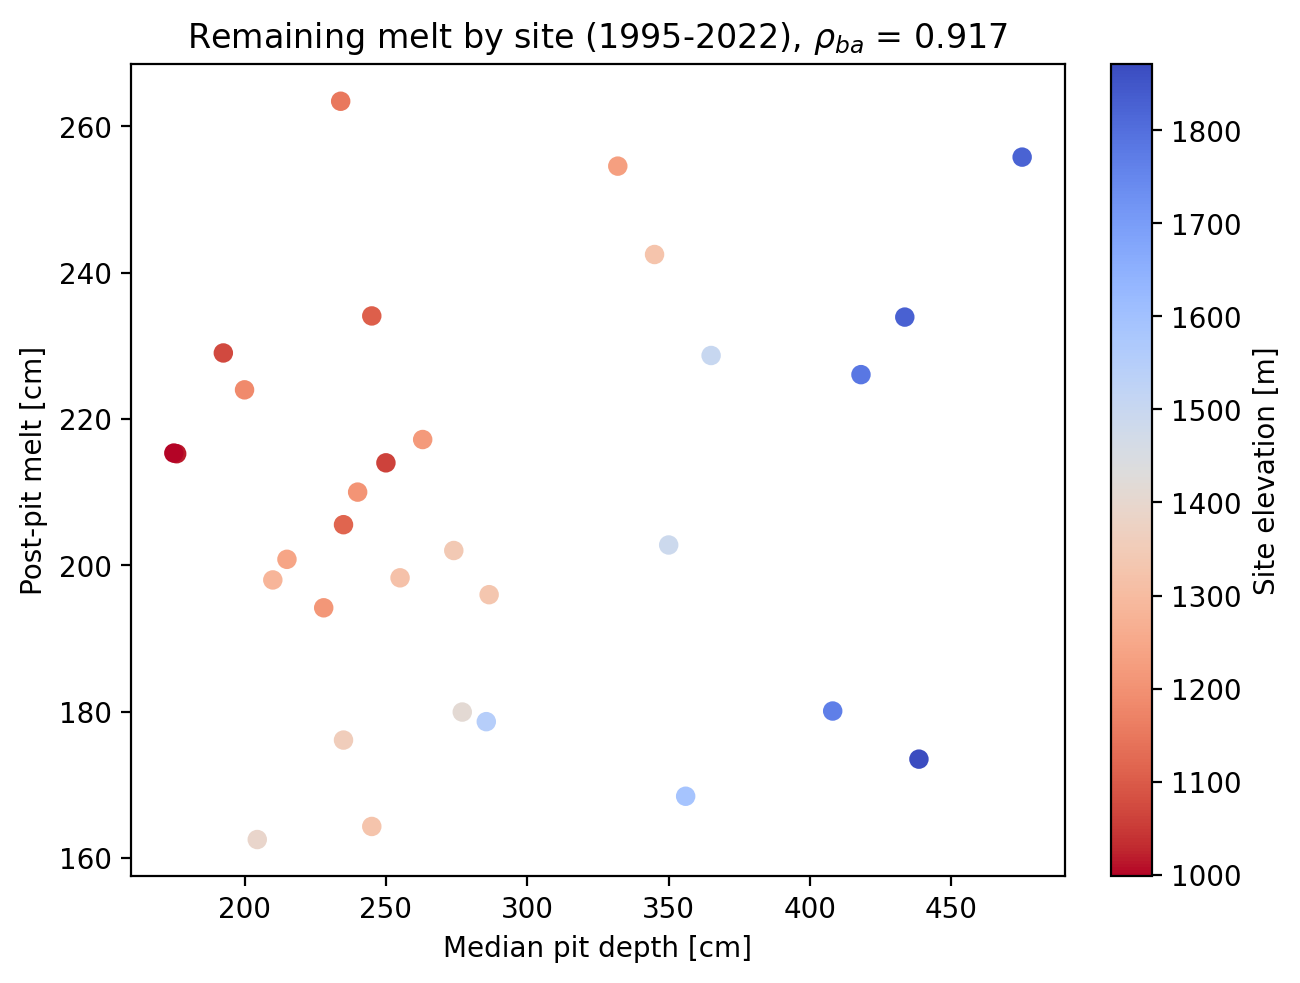

In [4]:
# median grouped by site
b_med = b.groupby(['site_name'])[['snow_depth_cm', 'pit_date', 'elevation', 'bw', 'ba', 'bs', 'pit_doy', 'mean_snow_density_gcm3']].median().reset_index()

b_med['melt_remaining'] = b_med.snow_depth_cm - b_med.ba * 100 / 0.917  # assuming ice densityb
fig, ax = plt.subplots(dpi=200, layout="constrained")
scat = ax.scatter(b_med.snow_depth_cm, b_med["melt_remaining"], c=b_med.elevation, cmap='coolwarm_r')
fig.colorbar(scat, label='Site elevation [m]')
ax.set_xlabel("Median pit depth [cm]")
ax.set_ylabel("Post-pit melt [cm]")
ax.set_title(r"Remaining melt by site (1995-2022), $\rho_{ba}$ = 0.917")
fig.savefig(Path(ROOT, "notebooks/estimate-post-pit-melt/melt-remaining-rho-917.png"))

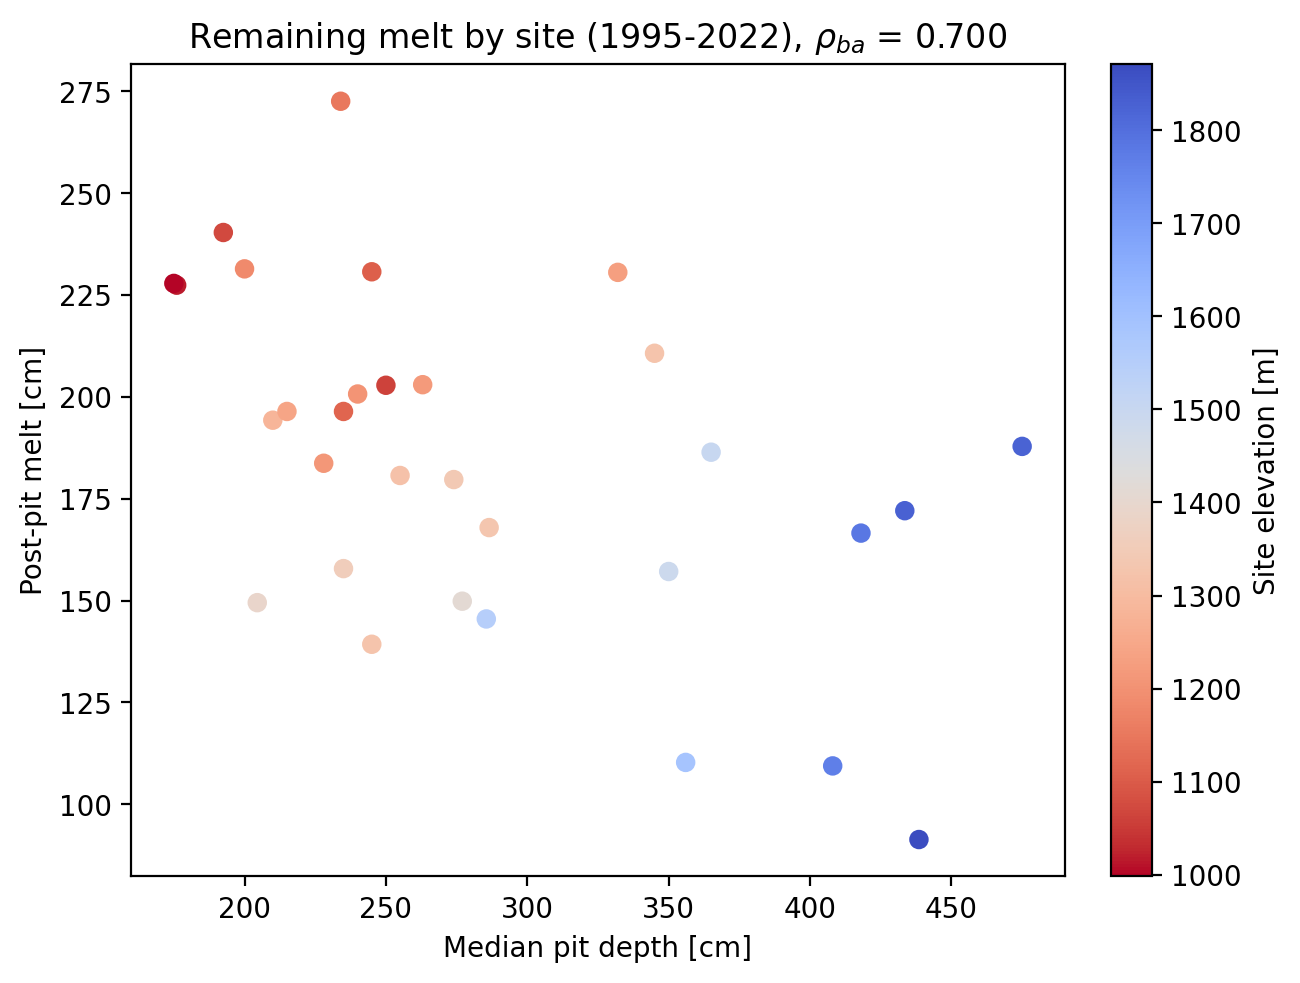

In [5]:
# median grouped by site
b_med = b.groupby(['site_name'])[['snow_depth_cm', 'pit_date', 'elevation', 'bw', 'ba', 'bs', 'pit_doy', 'mean_snow_density_gcm3']].median().reset_index()

b_med['melt_remaining'] = b_med.snow_depth_cm - b_med.ba * 100 / 0.700  # assuming firn density
fig, ax = plt.subplots(dpi=200, layout="constrained")
scat = ax.scatter(b_med.snow_depth_cm, b_med["melt_remaining"], c=b_med.elevation, cmap='coolwarm_r')
fig.colorbar(scat, label='Site elevation [m]')
ax.set_xlabel("Median pit depth [cm]")
ax.set_ylabel("Post-pit melt [cm]")
ax.set_title(r"Remaining melt by site (1995-2022), $\rho_{ba}$ = 0.700")
fig.savefig(Path(ROOT, "notebooks/estimate-post-pit-melt/melt-remaining-rho-700.png"))

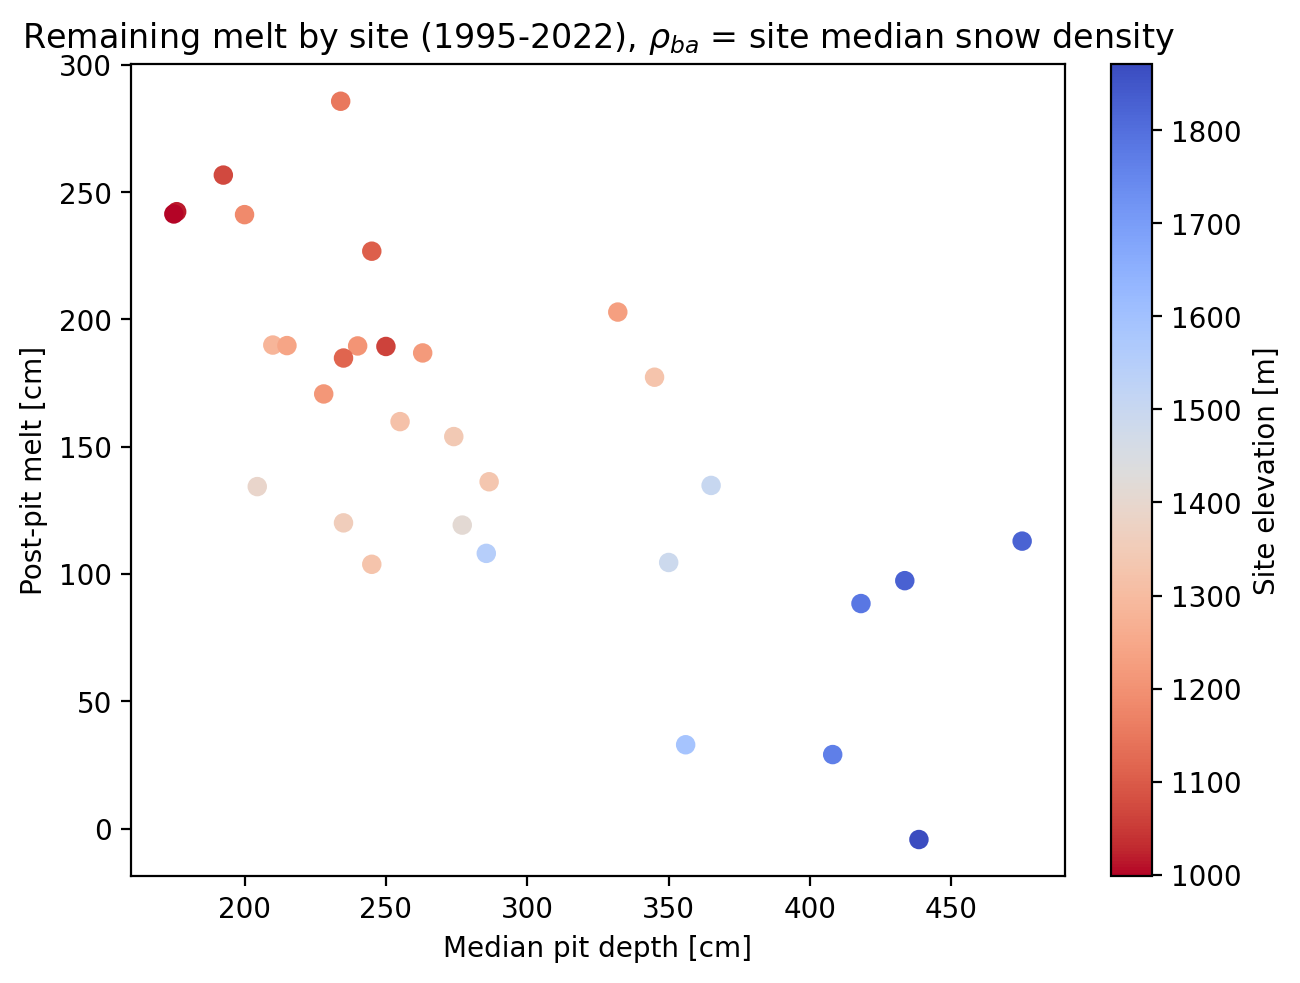

In [6]:
# median grouped by site
b_med = b.groupby(['site_name'])[['snow_depth_cm', 'pit_date', 'elevation', 'bw', 'ba', 'bs', 'pit_doy', 'mean_snow_density_gcm3']].median().reset_index()

b_med['melt_remaining'] = b_med.snow_depth_cm - b_med.ba * 100 / b_med.mean_snow_density_gcm3  # assuming snow density
fig, ax = plt.subplots(dpi=200, layout="constrained")
scat = ax.scatter(b_med.snow_depth_cm, b_med["melt_remaining"], c=b_med.elevation, cmap='coolwarm_r')
fig.colorbar(scat, label='Site elevation [m]')
ax.set_xlabel("Median pit depth [cm]")
ax.set_ylabel("Post-pit melt [cm]")
ax.set_title(r"Remaining melt by site (1995-2022), $\rho_{ba}$ = site median snow density")
fig.savefig(Path(ROOT, "notebooks/estimate-post-pit-melt/melt-remaining-rho-snow.png"))

/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_71447/4223182505.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(index)


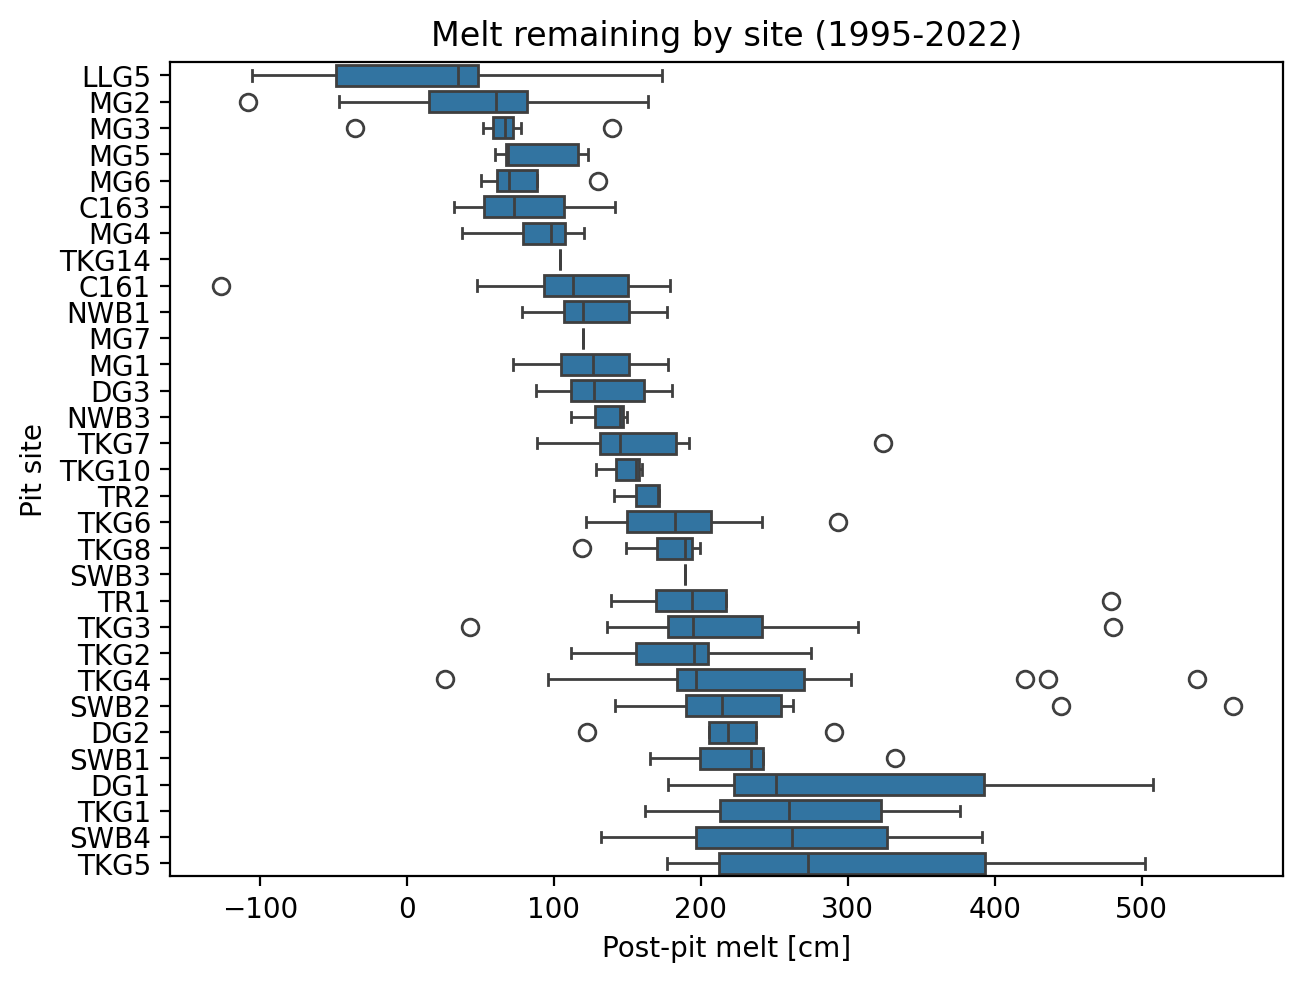

In [7]:
# calculate melt remaining for each record
b['melt_remaining_cm'] = b.snow_depth_cm - b.ba * 100 / b.mean_snow_density_gcm3

index = b.groupby('site_name')['melt_remaining_cm'].median().sort_values().index
fig, ax = plt.subplots(dpi=200, layout="constrained")
sns.boxplot(x=b.melt_remaining_cm, y=b.site_name, ax=ax, orient='y', order=index)
ax.set_yticklabels(index)
ax.set_ylabel("Pit site")
ax.set_xlabel("Post-pit melt [cm]")
ax.set_title("Melt remaining by site (1995-2022)")
fig.savefig(Path(ROOT, "notebooks/estimate-post-pit-melt/melt-remaining-by-site-sorted.png"))

/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_71447/3460902282.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(index)


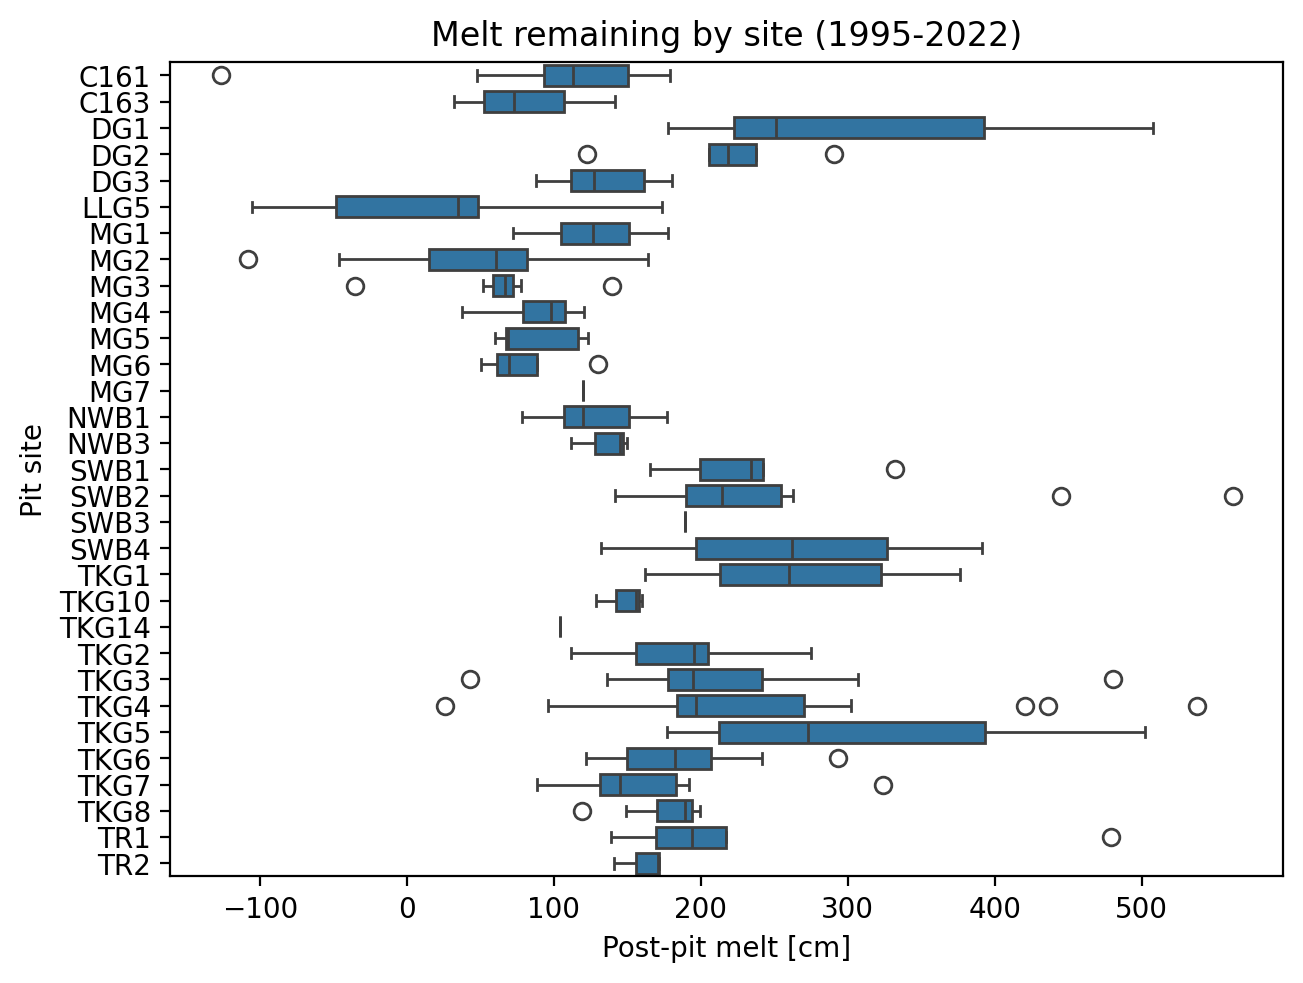

In [8]:
index = b.sort_values(by='site_name').groupby('site_name')['melt_remaining_cm'].median().index
fig, ax = plt.subplots(dpi=200, layout="constrained")
sns.boxplot(x=b.melt_remaining_cm, y=b.site_name, ax=ax, orient='y', order=index)
ax.set_yticklabels(index)
ax.set_ylabel("Pit site")
ax.set_xlabel("Post-pit melt [cm]")
ax.set_title("Melt remaining by site (1995-2022)")
fig.savefig(Path(ROOT, "notebooks/estimate-post-pit-melt/melt-remaining-by-site.png"))

/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_71447/1727063540.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(index)


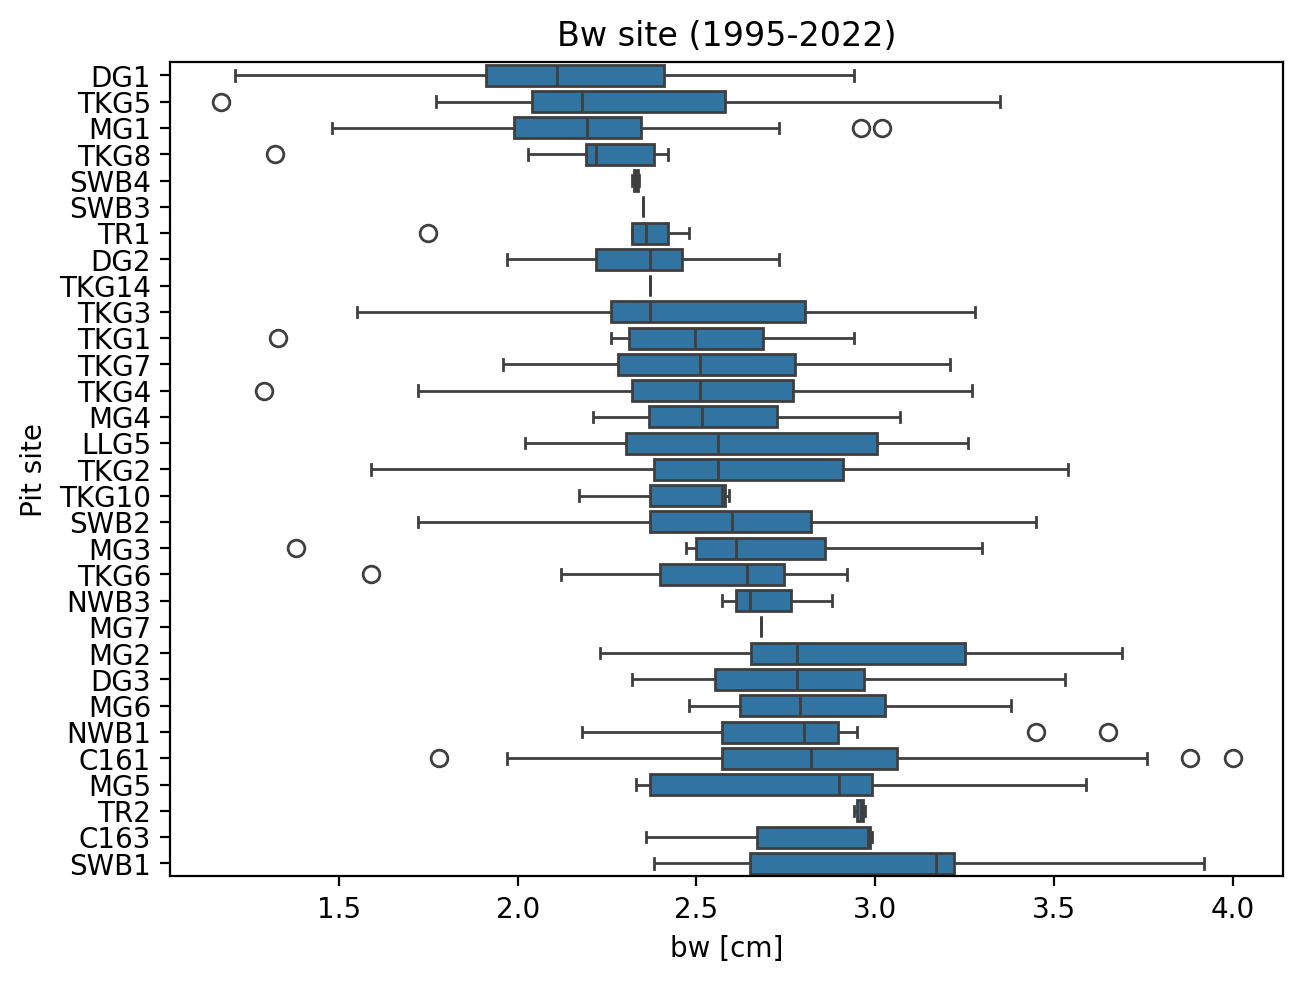

In [9]:
# plot winter balance range for each site.
index = b.groupby('site_name')['bw'].median().sort_values().index
fig, ax = plt.subplots(dpi=200, layout="constrained")
sns.boxplot(x=b.bw, y=b.site_name, ax=ax, orient='y', order=index)
ax.set_yticklabels(index)
ax.set_ylabel("Pit site")
ax.set_xlabel("bw [cm]")
ax.set_title("Bw site (1995-2022)")
fig.savefig(Path(ROOT, "notebooks/estimate-post-pit-melt/bw-by-site.png"))